# ДЗ 6. Детекція об'єктів у приміщенні (YOLOv9s)

Датасет Indoor Objects Detection (Kaggle, формат YOLO): 10 класів - door, cabinetDoor, refrigeratorDoor,
window, chair, table, cabinet, couch, openedDoor, pole. Дані вже розбиті на train / valid / test.

План: подивитись на дані, зібрати YAML-конфіг, дообучити YOLOv9s з COCO-вагами (ultralytics),
розібрати криві навчання, метрики по класах і матрицю помилок.

In [1]:
!pip install -q ultralytics kagglehub

In [2]:
import os, glob, shutil, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
import yaml
import torch
import kagglehub
from ultralytics import YOLO

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 0 if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

device: mps


## Дані

Завантаження через kagglehub. Розмітка YOLO: на кожне зображення txt-файл, рядок = `cls x_c y_c w h`,
координати відносні (0..1). Зображення без txt-файлу або з порожнім файлом - фон без об'єктів.

In [3]:
path = Path(kagglehub.dataset_download("thepbordin/indoor-object-detection"))
print("Path to dataset files:", path)

CLASSES = ["door", "cabinetDoor", "refrigeratorDoor", "window", "chair",
           "table", "cabinet", "couch", "openedDoor", "pole"]
SPLITS = ["train", "valid", "test"]

for split in SPLITS:
    n_img = len(os.listdir(path / split / "images"))
    n_lbl = len(os.listdir(path / split / "labels"))
    print(f"{split:6s} images={n_img:5d}  label files={n_lbl:5d}")

Path to dataset files: /Users/andyparshyn/.cache/kagglehub/datasets/thepbordin/indoor-object-detection/versions/1
train  images= 1012  label files= 1008
valid  images=  230  label files=  230
test   images=  107  label files=  104


## Знайомство з даними

In [4]:
rows, backgrounds = [], {}
for split in SPLITS:
    n_bg = 0
    for img_path in sorted(glob.glob(str(path / split / "images" / "*"))):
        lbl_path = path / split / "labels" / (Path(img_path).stem + ".txt")
        lines = open(lbl_path).read().strip().splitlines() if lbl_path.exists() else []
        if not lines:
            n_bg += 1
        for line in lines:
            c, x, y, w, h = line.split()
            rows.append(dict(split=split, image=Path(img_path).name, cls=CLASSES[int(c)],
                             x=float(x), y=float(y), w=float(w), h=float(h)))
    backgrounds[split] = n_bg

labels = pd.DataFrame(rows)
print("фонових зображень (без боксів):", backgrounds)
print("боксів усього:", len(labels))

counts = labels.pivot_table(index="cls", columns="split", values="image", aggfunc="count", fill_value=0)
counts = counts[SPLITS].loc[CLASSES]
counts["train_share_%"] = (100 * counts["train"] / counts["train"].sum()).round(1)
counts

фонових зображень (без боксів): {'train': 120, 'valid': 31, 'test': 3}
боксів усього: 7331


split,train,valid,test,train_share_%
cls,,,,
door,479,97,34,8.7
cabinetDoor,3178,765,179,57.9
refrigeratorDoor,689,192,2,12.5
window,403,91,63,7.3
chair,204,49,87,3.7
table,228,40,47,4.2
cabinet,179,32,52,3.3
couch,27,1,58,0.5
openedDoor,78,13,20,1.4


боксів на зображення (train): mean=6.2, max=54
найчастіші розміри зображень (train):
(1024, 768)     262
(768, 1024)     127
(1024, 683)      80
(1024, 1024)     47
(1024, 681)      29
Name: count, dtype: int64


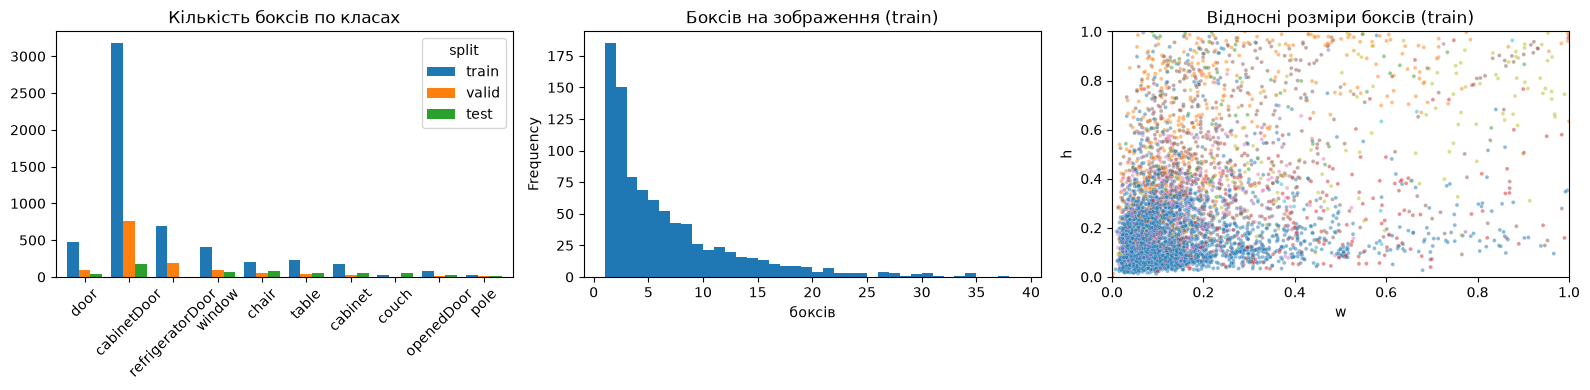

cls
door                 6.79
cabinetDoor          1.20
refrigeratorDoor     6.98
window               1.67
chair                2.73
table                7.51
cabinet             15.06
couch                6.18
openedDoor          10.17
pole                 4.35
Name: median_area_%, dtype: float64

In [5]:
boxes_per_img = labels.groupby(["split", "image"]).size()
sizes = pd.Series([Image.open(p).size for p in glob.glob(str(path / "train/images/*"))]).value_counts()
print("боксів на зображення (train): mean=%.1f, max=%d" % (boxes_per_img["train"].mean(), boxes_per_img["train"].max()))
print("найчастіші розміри зображень (train):")
print(sizes.head(5))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
counts[SPLITS].plot.bar(ax=axes[0], width=0.8)
axes[0].set_title("Кількість боксів по класах"); axes[0].set_xlabel(""); axes[0].tick_params(axis="x", rotation=45)

boxes_per_img["train"].plot.hist(bins=range(1, 40), ax=axes[1])
axes[1].set_title("Боксів на зображення (train)"); axes[1].set_xlabel("боксів")

tr = labels[labels.split == "train"]
sns.scatterplot(data=tr, x="w", y="h", hue="cls", s=8, alpha=0.5, ax=axes[2], legend=False)
axes[2].set_title("Відносні розміри боксів (train)"); axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1)
plt.tight_layout(); plt.show()

# медіанна відносна площа боксу по класах: дрібні об'єкти детектувати важче
(tr.assign(area=tr.w * tr.h).groupby("cls")["area"].median().loc[CLASSES] * 100).round(2).rename("median_area_%")

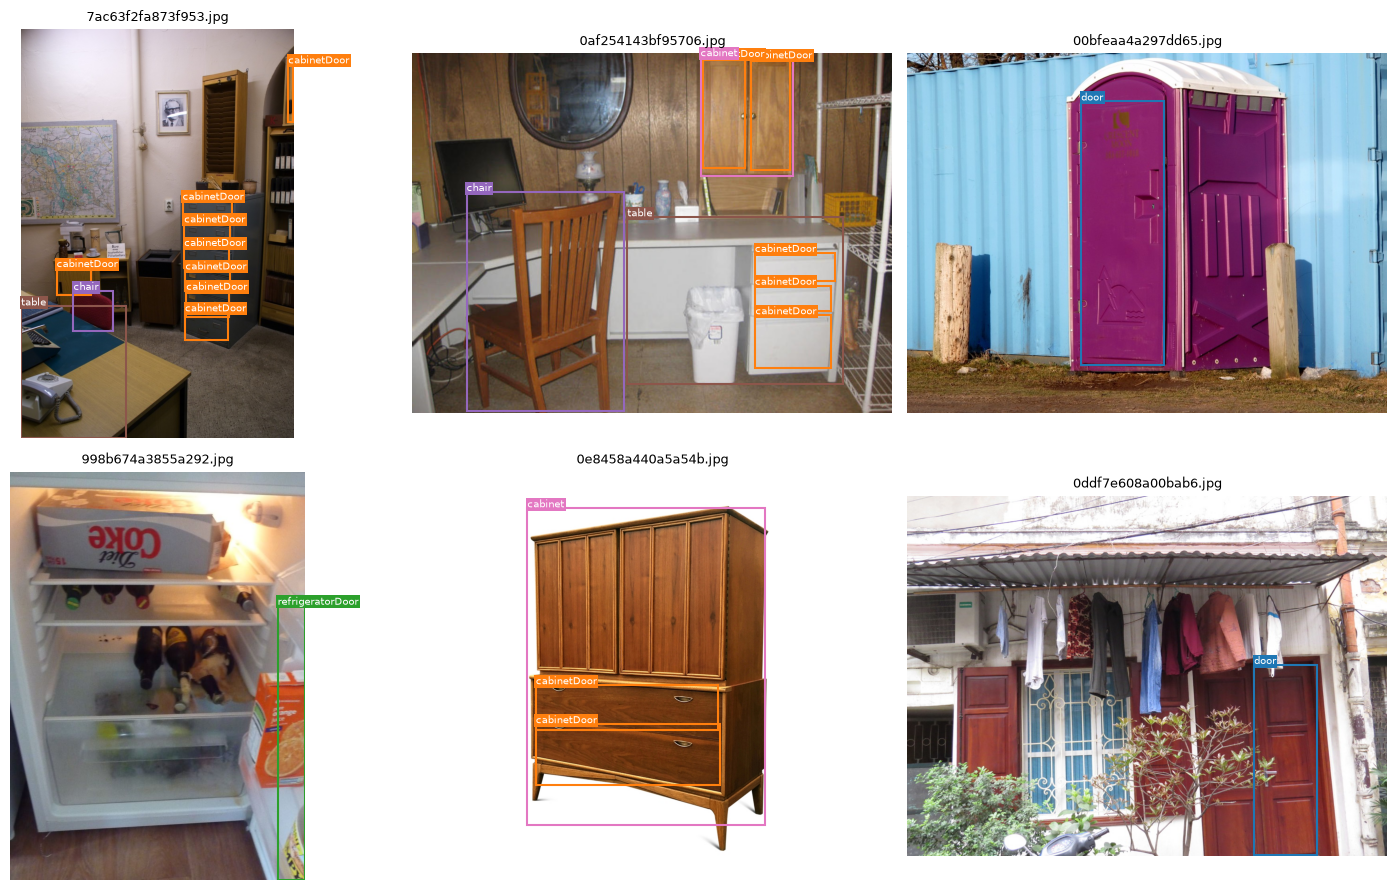

In [6]:
COLORS = plt.cm.tab10(np.arange(len(CLASSES)))

def draw_boxes(ax, img_path, lbl_path, title=""):
    img = Image.open(img_path).convert("RGB")
    W, H = img.size
    ax.imshow(img); ax.axis("off"); ax.set_title(title, fontsize=9)
    if not Path(lbl_path).exists():
        return
    for line in open(lbl_path).read().strip().splitlines():
        c, x, y, w, h = map(float, line.split())
        x0, y0 = (x - w / 2) * W, (y - h / 2) * H
        ax.add_patch(patches.Rectangle((x0, y0), w * W, h * H, fill=False, lw=1.5, color=COLORS[int(c)]))
        ax.text(x0, y0 - 2, CLASSES[int(c)], fontsize=7, color="white",
                bbox=dict(facecolor=COLORS[int(c)], pad=1, lw=0))

sample = random.sample(sorted(glob.glob(str(path / "train/images/*"))), 6)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, p in zip(axes.flat, sample):
    draw_boxes(ax, p, path / "train/labels" / (Path(p).stem + ".txt"), Path(p).name)
plt.tight_layout(); plt.show()

## Конфігурація YOLO (YAML)

Шляхи до сплітів беру з kagglehub, порядок імен класів фіксований, він і задає індекси в txt-розмітці.

In [7]:
data_cfg = {
    "path": str(path),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(CLASSES),
    "names": CLASSES,
}
with open("indoor.yaml", "w") as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)
print(open("indoor.yaml").read())

path: /Users/andyparshyn/.cache/kagglehub/datasets/thepbordin/indoor-object-detection/versions/1
train: train/images
val: valid/images
test: test/images
nc: 10
names:
- door
- cabinetDoor
- refrigeratorDoor
- window
- chair
- table
- cabinet
- couch
- openedDoor
- pole


## Модель і навчання

YOLOv9s: одностадійний anchor-free детектор, 7.2M параметрів, 26.7 GFLOPs. Від YOLOv8 відрізняється
бекбоном GELAN і допоміжною гілкою PGI (programmable gradient information), яка дає кращі градієнти
глибоким шарам під час навчання і прибирається на інференсі. Стартую з COCO-ваг, дообучаю всю мережу:
для 1000 картинок навчання з нуля не має сенсу, а в COCO вже є chair, couch, table, refrigerator, door.

Лосс складається з трьох частин: box (CIoU), cls (BCE по класах), dfl (distribution focal loss для
координат боксу). 30 епох при 640 px, батч 16. На T4 у Colab це близько 15 хв, на M4 Pro (MPS) близько 45 хв.

In [8]:
EPOCHS = 30
IMG_SIZE = 640
BATCH = 16
PROJECT = str(Path.cwd() / "runs")  # відносний project ultralytics 8.4 кладе у свій глобальний runs_dir

model = YOLO("yolov9s.pt")
results = model.train(
    data="indoor.yaml",
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=device,
    seed=SEED,
    patience=10,
    project=PROJECT,
    name="yolov9s_indoor",
    exist_ok=True,
    plots=True,
)
run_dir = Path(results.save_dir)
print("run dir:", run_dir)

Ultralytics 8.4.150 🚀 Python-3.12.14 torch-2.13.0 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=indoor.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov9s_indoor, nbs=64, nms=None, opset=None, optimize=False, optimizer=auto, 

In [9]:
os.makedirs("weights", exist_ok=True)
best_path = shutil.copy(run_dir / "weights" / "best.pt", "weights/yolov9s_indoor_best.pt")
print(best_path, "%.1f MB" % (os.path.getsize(best_path) / 1e6))

# у Colab, щоб ваги пережили сесію:
# from google.colab import drive; drive.mount("/content/drive")
# shutil.copy(best_path, "/content/drive/MyDrive/yolov9s_indoor_best.pt")

weights/yolov9s_indoor_best.pt 15.2 MB


## Аналіз результатів

### Криві навчання

results.csv пише ultralytics після кожної епохи. Порівнюю train і val для кожної складової лоссу,
окремо дивлюсь на mAP, precision, recall.

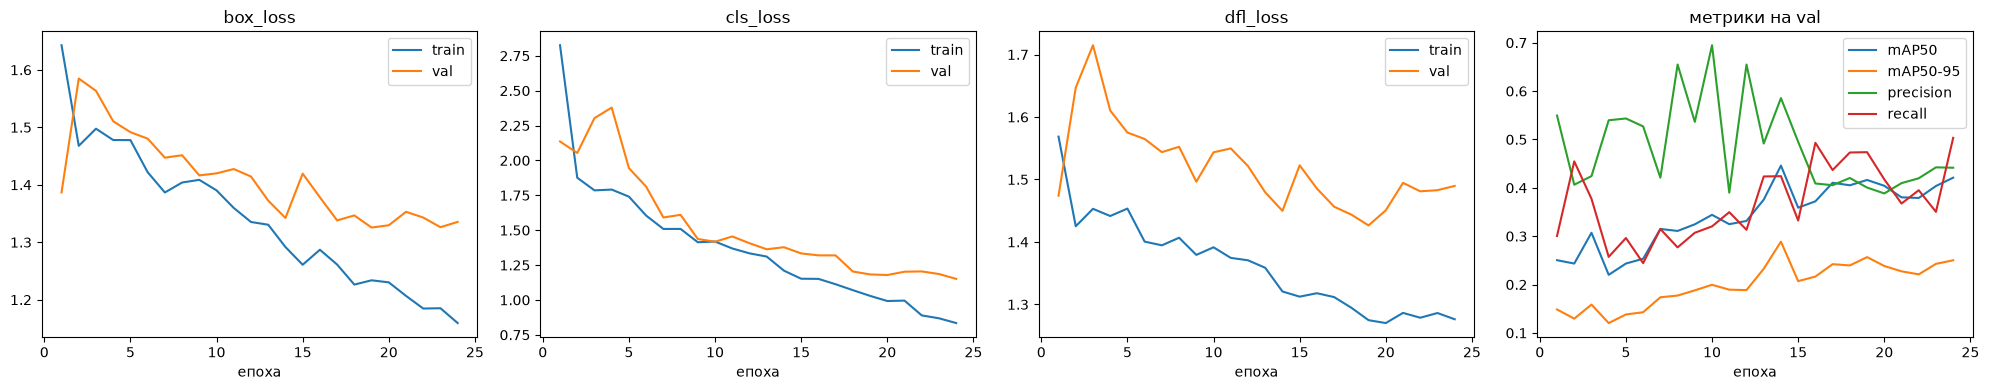

найкраща епоха за mAP50-95: 14


,epoch,train/box_loss,val/box_loss,train/cls_loss,val/cls_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
0,1,1.643,1.387,2.826,2.136,0.549,0.300,0.250,0.148
12,13,1.330,1.372,1.311,1.363,0.492,0.423,0.375,0.233
13,14,1.292,1.342,1.210,1.378,0.586,0.424,0.446,0.289
23,24,1.159,1.335,0.834,1.151,0.442,0.503,0.421,0.250


In [10]:
hist = pd.read_csv(run_dir / "results.csv")
hist.columns = hist.columns.str.strip()
ep = hist["epoch"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, part in zip(axes[:3], ["box_loss", "cls_loss", "dfl_loss"]):
    ax.plot(ep, hist[f"train/{part}"], label="train")
    ax.plot(ep, hist[f"val/{part}"], label="val")
    ax.set_title(part); ax.set_xlabel("епоха"); ax.legend()
for m, lbl in [("metrics/mAP50(B)", "mAP50"), ("metrics/mAP50-95(B)", "mAP50-95"),
               ("metrics/precision(B)", "precision"), ("metrics/recall(B)", "recall")]:
    axes[3].plot(ep, hist[m], label=lbl)
axes[3].set_title("метрики на val"); axes[3].set_xlabel("епоха"); axes[3].legend()
plt.tight_layout(); plt.show()

best_ep = hist["metrics/mAP50-95(B)"].idxmax()
cols = ["epoch", "train/box_loss", "val/box_loss", "train/cls_loss", "val/cls_loss",
        "metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)", "metrics/mAP50-95(B)"]
print("найкраща епоха за mAP50-95:", int(hist.loc[best_ep, "epoch"]))
hist.loc[[0, len(hist) // 2, best_ep, len(hist) - 1], cols].round(3)

Навчання зупинилось раніше 30 епох: EarlyStopping з patience=10 спрацював на 24-й епосі, найкраща
за mAP50-95 епоха 14 (mAP50 0.446, mAP50-95 0.289), best.pt збережений з неї.

Що видно на кривих:
- train/box і train/cls падають монотонно до кінця (box 1.64 -> 1.16, cls 2.83 -> 0.83).
- val/box перестає падати приблизно з 13-14 епохи і далі тримається на 1.33-1.35, val/cls ще
  повільно спадає (1.15 на 24-й). Розрив train-val по box невеликий (0.17), по cls - 0.3 і зростає.
  Це початок перенавчання, а не сильне перенавчання: val-лосси не ростуть, вони вийшли на плато.
- mAP на val дуже шумний: 0.446 на 14-й, 0.359 на 15-й, потім коливання 0.37-0.42. Валідація мала
  (230 картинок, 1289 боксів, 59% з них cabinetDoor), тож одна епоха з вдалою підгонкою рідких класів
  дає викид. Через цей шум patience=10 зупинив навчання до того, як спрацював close_mosaic
  (останні 10 епох без mosaic-аугментації), де зазвичай метрики ще підростають.
- Precision (0.4-0.7) стабільно вища за recall (0.3-0.5): модель радше пропускає об'єкти, ніж вигадує.

Недонавчання по train немає, лосс ще падає. Верхня межа тут задається даними (мало прикладів рідких
класів, шумна валідація), а не кількістю епох.

### Оцінка на валідації та метрики по класах

Валідую best.pt окремо через `model.val`: звідти беру precision, recall, F1, AP50 і AP50-95 по кожному
класу. P, R, F1 ultralytics рахує при порозі confidence, що максимізує F1, AP - інтегрально по всіх порогах.

In [11]:
model = YOLO("weights/yolov9s_indoor_best.pt")
val_metrics = model.val(data="indoor.yaml", split="val", device=device, plots=True,
                        project=PROJECT, name="yolov9s_indoor_val", exist_ok=True)

print("VALID: precision=%.3f  recall=%.3f  mAP50=%.3f  mAP50-95=%.3f" % tuple(val_metrics.box.mean_results()))

Ultralytics 8.4.150 🚀 Python-3.12.14 torch-2.13.0 MPS (Apple M4 Pro)
YOLOv9s summary (fused): 197 layers, 7,170,958 parameters, 0 gradients, 26.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5995.3±3068.2 MB/s, size: 469.3 KB)
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 6% ╸─────────── 1/15 1.1s/it 0.3s<14.8s
                   all        230       1289      0.582       0.42      0.445      0.289
                  door         63         97      0.447      0.412      0.405      0.221
           cabinetDoor         99        765      0.888      0.641      0.783      0.453
      refrigeratorDoor         85        192      0.746      0.766      0.696      0.456
                window         39         91       0.39      0.374      0.319      0.195
                 chair         24         49      0.477      0.612      0.541      0.239
                 table         30         40       0.55       0.05      0.176      0.103
        

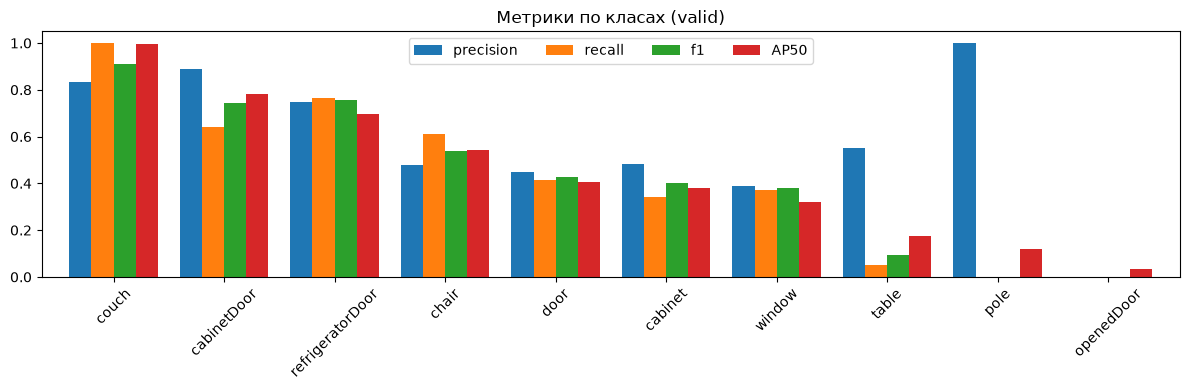

найкращі за AP50: couch, cabinetDoor, refrigeratorDoor
найгірші за AP50: table, pole, openedDoor


,n_val,precision,recall,f1,AP50,AP50-95
class,,,,,,
couch,1,0.835,1.000,0.910,0.995,0.896
cabinetDoor,765,0.888,0.641,0.744,0.783,0.453
refrigeratorDoor,192,0.746,0.766,0.756,0.696,0.456
chair,49,0.477,0.612,0.536,0.541,0.239
door,97,0.447,0.412,0.429,0.405,0.221
cabinet,32,0.485,0.344,0.402,0.382,0.275
window,91,0.390,0.374,0.381,0.319,0.195
table,40,0.550,0.050,0.092,0.176,0.103
pole,9,1.000,0.000,0.000,0.121,0.036


In [12]:
b = val_metrics.box
per_class = pd.DataFrame({
    "class": [CLASSES[i] for i in b.ap_class_index],
    "n_val": counts.loc[[CLASSES[i] for i in b.ap_class_index], "valid"].values,
    "precision": b.p, "recall": b.r, "f1": b.f1, "AP50": b.ap50, "AP50-95": b.ap,
}).set_index("class").sort_values("AP50", ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
per_class[["precision", "recall", "f1", "AP50"]].plot.bar(ax=ax, width=0.8)
ax.set_title("Метрики по класах (valid)"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=45); ax.legend(ncol=4)
plt.tight_layout(); plt.show()

print("найкращі за AP50:", ", ".join(per_class.index[:3]))
print("найгірші за AP50:", ", ".join(per_class.index[-3:]))
per_class.round(3)

Найкраще: cabinetDoor (AP50 0.78, precision 0.89) і refrigeratorDoor (AP50 0.70, P і R по 0.75).
Це два найчисельніші класи (58% і 12.5% train-боксів), прості прямокутні форми, багато повторів у
кадрі. chair теж пристойно (AP50 0.54) при 204 train-прикладах, форма дуже характерна.

couch з AP50 0.995 не рахується: у валідації один екземпляр.

Найгірше:
- openedDoor (AP50 0.03, F1 0): 78 train-боксів, 13 на val. Візуально це той самий door, різниця в
  стані (щілина, видимий одвірок), модель її не вивчила.
- pole (AP50 0.12, recall 0): 27 train-боксів, довгі тонкі об'єкти, для яких CIoU і anchor-free
  голова дають нестабільний бокс.
- table (AP50 0.18, recall 0.05 при precision 0.55): 228 train-боксів, тобто справа не тільки в
  кількості. Стіл великий, частково закритий стільцями, і межі боксу неоднозначні (стільниця чи все
  разом), тож і розмітка навряд чи консистентна.

door і window посередині (AP50 0.40 і 0.32): багато екземплярів, але висока варіативність (шибки,
рами, штори, скляні двері) і плутанина з cabinetDoor, див. матрицю далі.

### Матриця помилок

Матриця ultralytics: рядки - передбачений клас, стовпці - справжній, останній індекс - фон
(стовпець background = хибні спрацювання, рядок background = пропущені об'єкти). Рахується при
conf 0.25 і IoU 0.45. Нормалізую по стовпцях: скільки об'єктів кожного справжнього класу куди пішли.

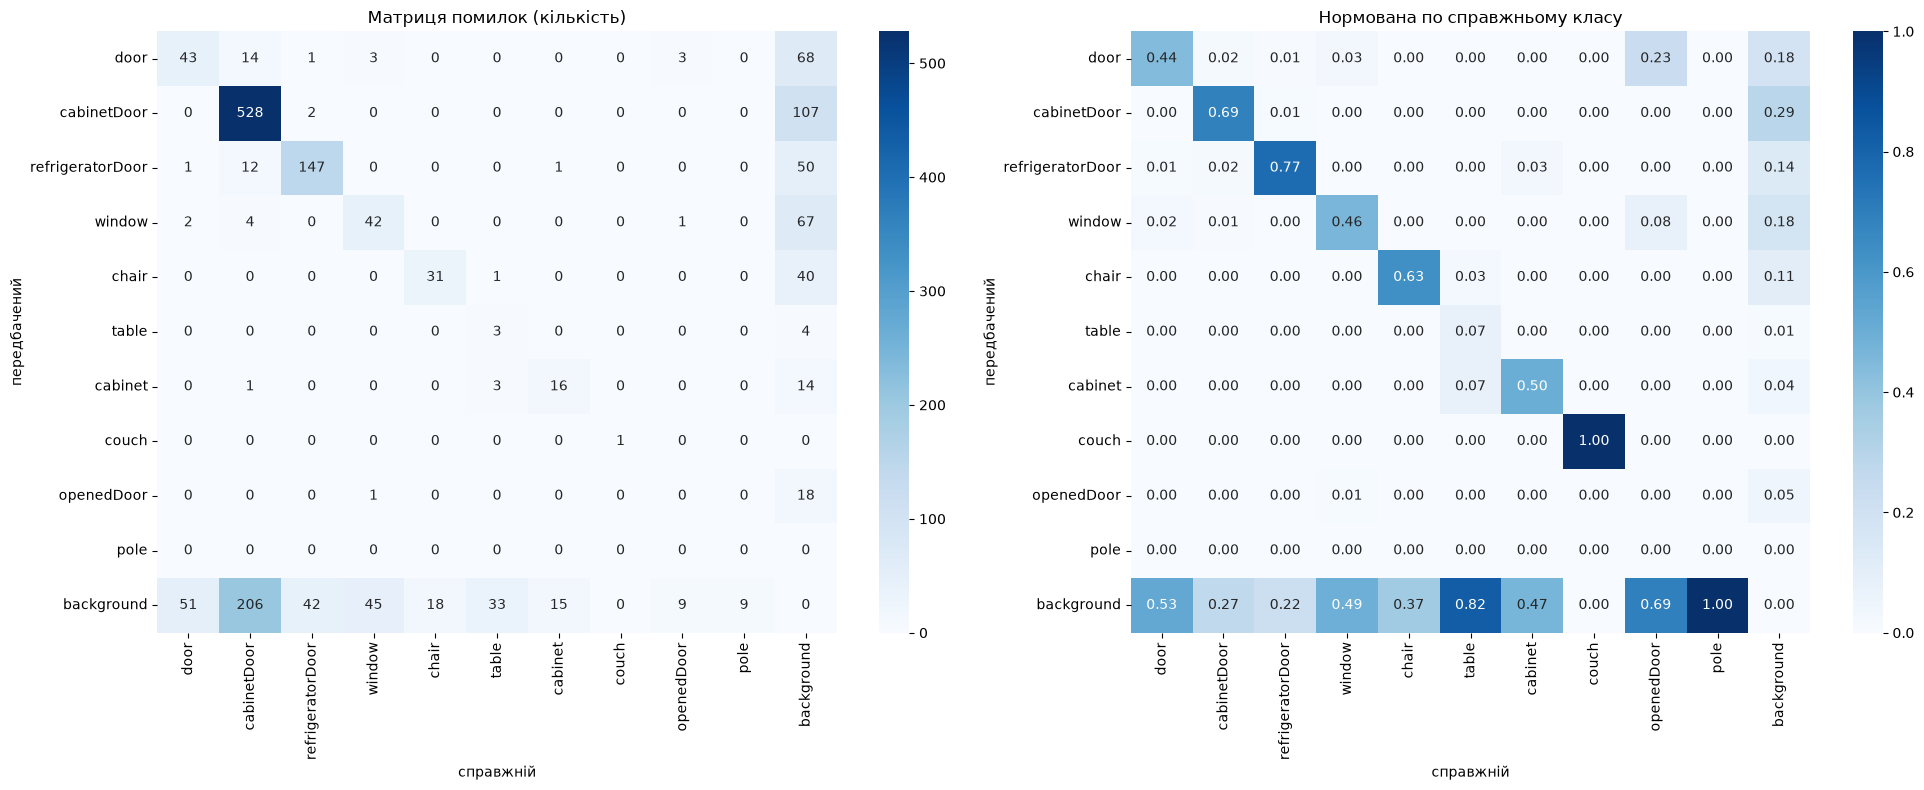

найчастіші плутанини між класами:


,true,predicted,count,share_of_true
2,cabinetDoor,door,14,0.018
3,cabinetDoor,refrigeratorDoor,12,0.016
4,cabinetDoor,window,4,0.005
8,window,door,3,0.033
11,table,cabinet,3,0.075
13,openedDoor,door,3,0.231
1,door,window,2,0.021
7,refrigeratorDoor,cabinetDoor,2,0.010


,instances,detected_correctly,missed_%,wrong_class_%,false_positives
door,97,43,52.6,3.1,68
cabinetDoor,765,528,26.9,4.1,107
refrigeratorDoor,192,147,21.9,1.6,50
window,91,42,49.5,4.4,67
chair,49,31,36.7,0.0,40
table,40,3,82.5,10.0,4
cabinet,32,16,46.9,3.1,14
couch,1,1,0.0,0.0,0
openedDoor,13,0,69.2,30.8,18
pole,9,0,100.0,0.0,0


In [13]:
cm = val_metrics.confusion_matrix.matrix
names_bg = CLASSES + ["background"]
cm_norm = cm / cm.sum(axis=0, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm.astype(int), annot=True, fmt="d", cmap="Blues", xticklabels=names_bg, yticklabels=names_bg, ax=axes[0])
axes[0].set_title("Матриця помилок (кількість)"); axes[0].set_xlabel("справжній"); axes[0].set_ylabel("передбачений")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=names_bg, yticklabels=names_bg, ax=axes[1])
axes[1].set_title("Нормована по справжньому класу"); axes[1].set_xlabel("справжній"); axes[1].set_ylabel("передбачений")
plt.tight_layout(); plt.show()

nc = len(CLASSES)
pairs = [(names_bg[t], names_bg[p], int(cm[p, t]), cm_norm[p, t])
         for t in range(nc) for p in range(nc) if p != t and cm[p, t] > 0]
confused = pd.DataFrame(pairs, columns=["true", "predicted", "count", "share_of_true"]).sort_values("count", ascending=False)
print("найчастіші плутанини між класами:")
display(confused.head(8).round(3))

summary = pd.DataFrame({
    "instances": cm[:, :nc].sum(axis=0).astype(int),
    "detected_correctly": np.diag(cm)[:nc].astype(int),
    "missed_%": (100 * cm_norm[nc, :nc]).round(1),
    "wrong_class_%": (100 * (1 - cm_norm[nc, :nc] - np.diag(cm_norm)[:nc])).round(1),
    "false_positives": cm[:nc, nc].astype(int),
}, index=CLASSES)
summary

Головний тип помилки - не плутанина між класами, а пропуски (рядок background): door пропущено 53%,
window 50%, table 83%, openedDoor 69%, pole 100%. Частка "знайдено, але не той клас" по більшості
класів 0-4%, тобто якщо бокс є, клас майже завжди правильний.

Міжкласові пари, які все ж є:
- cabinetDoor -> door (14) і cabinetDoor -> refrigeratorDoor (12): у абсолютних числах найбільше,
  але це 1.6-1.8% від 765 екземплярів. Дверцята шафи, холодильника і звичайні двері - однакові
  вертикальні прямокутники з ручкою, розмір у кадрі залежить від відстані, тому масштаб не рятує.
- openedDoor -> door (3 з 13, 23%): очікувано, це той самий об'єкт в іншому стані. Плюс 18 хибних
  спрацювань openedDoor на фон.
- table -> cabinet (3 з 40) і window -> door (3 з 91): схожа геометрія, дерев'яні фасади.

Хибні спрацювання (стовпець background) найбільші у cabinetDoor (107), door (68), window (67):
модель бачить "прямокутник у стіні" і ставить бокс, коли розмітки там немає. Частина цього -
пропуски в розмітці, а не помилки моделі. На прикладах вище це видно: у 0ddf7e608a00bab6.jpg з двох
однакових червоних дверей розмічені одні, вікно з решіткою не розмічене зовсім. У тестовому 1167.png
(у моєму запуску він потрапив у приклади нижче) розмітки немає, хоча в кадрі комод з дверцятами і двері, а модель їх знаходить.

### Тестовий набір і приклади передбачень

Тест модель під час навчання не бачила і за ним не обирались ваги, тож це чесна оцінка.

In [14]:
test_metrics = model.val(data="indoor.yaml", split="test", device=device, plots=False,
                         project=PROJECT, name="yolov9s_indoor_test", exist_ok=True)
print("TEST:  precision=%.3f  recall=%.3f  mAP50=%.3f  mAP50-95=%.3f" % tuple(test_metrics.box.mean_results()))

Ultralytics 8.4.150 🚀 Python-3.12.14 torch-2.13.0 MPS (Apple M4 Pro)
YOLOv9s summary (fused): 197 layers, 7,170,958 parameters, 0 gradients, 26.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1178.2±157.2 MB/s, size: 344.4 KB)
                   all        107        550      0.562      0.292      0.333      0.191
                  door         25         34      0.733      0.118      0.198      0.111
           cabinetDoor         42        179      0.637      0.313      0.393      0.143
      refrigeratorDoor          1          2      0.536          1      0.995      0.696
                window         49         63       0.43      0.667      0.535      0.313
                 chair         38         87      0.398      0.356      0.328      0.168
                 table         41         47      0.329     0.0213      0.143     0.0695
               cabinet         44         52      0.544      0.154      0.276      0.172
                 couch         31         58      

На тесті mAP50 0.333 проти 0.445 на валідації. Причина видна в таблиці розподілу класів: тест
розбитий не випадково. couch там 58 боксів (у train 27, у valid 1), refrigeratorDoor 2 (у train 689),
chair 87, cabinet 52. Тобто тест зважений у бік саме тих класів, де модель слабка, і майже не містить
cabinetDoor, який тягне val-метрику вгору. Це оцінка ближча до реальної.

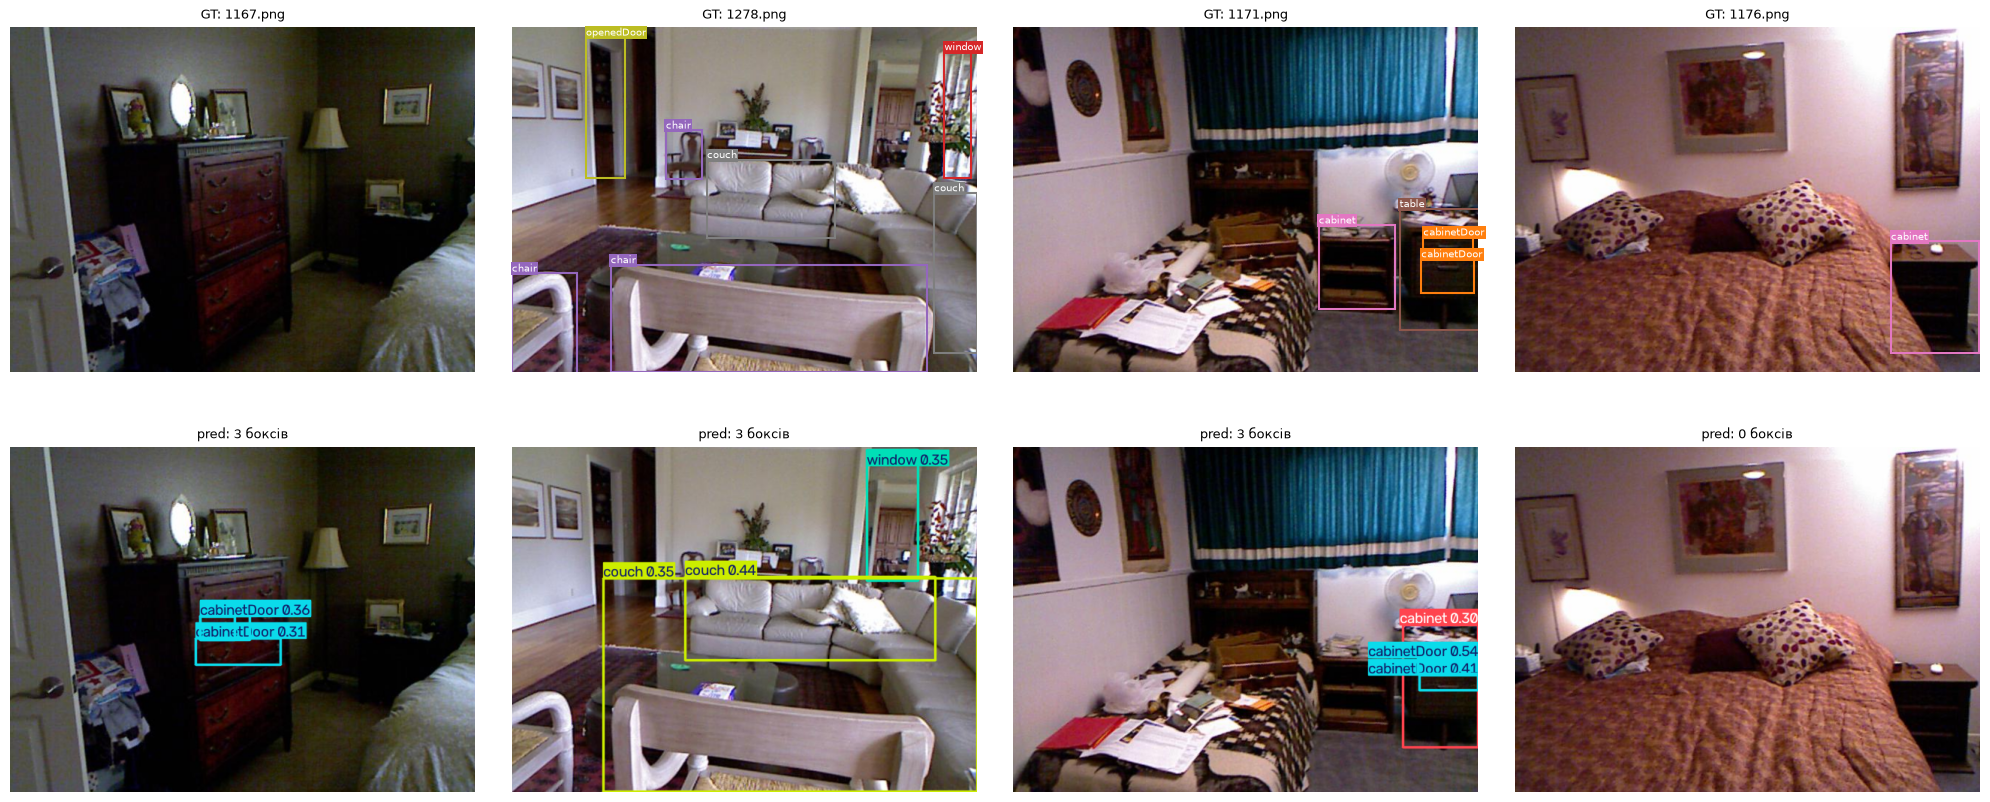

In [15]:
test_imgs = random.sample(sorted(glob.glob(str(path / "test/images/*"))), 4)
preds = model.predict(test_imgs, conf=0.25, device=device, verbose=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for j, (p, res) in enumerate(zip(test_imgs, preds)):
    draw_boxes(axes[0, j], p, path / "test/labels" / (Path(p).stem + ".txt"), "GT: " + Path(p).name)
    axes[1, j].imshow(res.plot(line_width=2, font_size=8)[:, :, ::-1]); axes[1, j].axis("off")
    axes[1, j].set_title("pred: %d боксів" % len(res.boxes), fontsize=9)
plt.tight_layout(); plt.show()

## Висновки та рекомендації

Що вийшло: YOLOv9s після 14 епох дає на валідації precision 0.58, recall 0.42, mAP50 0.445,
mAP50-95 0.289; на тесті mAP50 0.333, mAP50-95 0.191. Це робочий базовий детектор для cabinetDoor,
refrigeratorDoor і chair (AP50 0.54-0.78), але не для решти. Мета "впевнена детекція 10 класів
у приміщенні" не досягнута: openedDoor, pole і table модель практично не знаходить, door і window
пропускає в половині випадків.

Головні причини, у порядку впливу:
1. Дисбаланс даних: 58% боксів - cabinetDoor, у pole і couch по 0.5%. Модель оптимізує сумарний
   лосс і рідкі класи їй майже не коштують.
2. Мало даних взагалі (1012 картинок) плюс шумна і зміщена валідація: одна епоха дає стрибок mAP
   на 0.09, EarlyStopping зупиняє на випадковому піку.
3. Семантично близькі класи: door / openedDoor / cabinetDoor / refrigeratorDoor - один візуальний
   патерн, різниця в контексті і стані.
4. Пропуски і неконсистентність розмітки (незначені дверцята, різні межі для table), що видно з
   великої кількості "хибних" спрацювань на фон.

Що робити далі, конкретно:
- Навчати довше і без ранньої зупинки на шумній валідації: 60-100 епох, patience 30 або 0,
  щоб дійти до фази close_mosaic. Оцінювати за середнім по кількох останніх епохах.
- Перебалансувати: оверсемплінг картинок з pole, openedDoor, couch, table (повторити їх у
  train-списку 3-5 разів) або copy-paste аугментація цих об'єктів на інші фони.
- Об'єднати door і openedDoor в один клас door і за потреби визначати стан окремим бінарним
  класифікатором на кропі: детектор перестане вибирати між двома майже однаковими класами.
- Збільшити imgsz до 800-1024: медіанна площа cabinetDoor 1.2% кадру, дрібні об'єкти виграють
  від роздільної здатності більше, ніж від глибини мережі. Якщо є GPU, паралельно спробувати
  YOLOv9m або YOLO11m.
- Перевірити розмітку table і незначені дверцята на train, виправити або дорозмітити, це дешевше,
  ніж міняти модель.
- Перерозбити train/valid/test стратифіковано по класах, щоб test і valid мали той самий розподіл,
  інакше вибір найкращої епохи по valid не переноситься на test.
- Для продакшн-використання підбирати поріг confidence по класах (для door/window нижче, для
  cabinetDoor вище), бо precision і recall у них сильно різні.
